In [2]:
import chainladder as cl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%config InlineBackend.figure_format = 'retina'


In [2]:
dev = cl.Development().fit(cl.load_sample('ukmotor'))
type(dev.cdf_)

chainladder.core.triangle.Triangle

In [3]:
dev.cdf_

,12-Ult,24-Ult,36-Ult,48-Ult,60-Ult,72-Ult
(All),3.2914,1.7422,1.3586,1.1843,1.0799,1.0275


In [4]:
dev.ldf_

,12-24,24-36,36-48,48-60,60-72,72-84
(All),1.8892,1.2824,1.1471,1.0968,1.0509,1.0275


In [5]:
dev.ldf_.incr_to_cum()

,12-Ult,24-Ult,36-Ult,48-Ult,60-Ult,72-Ult
(All),3.2914,1.7422,1.3586,1.1843,1.0799,1.0275


In [6]:
raa = cl.load_sample('raa')

In [7]:
cl.Development(average='simple')

,n_periods,-1
,average,'simple'
,sigma_interpolation,'log-linear'
,drop,None
,drop_high,None
,drop_low,None
,preserve,1
,drop_valuation,None
,drop_above,inf
,drop_below,0.0
,fillna,None


In [8]:
raa.link_ratio.development

0      12-24
1      24-36
2      36-48
3      48-60
4      60-72
5      72-84
6      84-96
7     96-108
8    108-120
Name: development, dtype: object

In [9]:
['volume'] + ['simple'] * 8

['volume',
 'simple',
 'simple',
 'simple',
 'simple',
 'simple',
 'simple',
 'simple',
 'simple']

In [10]:
cl.Development(average=['volume'] + ['simple']*8)

,n_periods,-1
,average,"['volume', 'simple', ...]"
,sigma_interpolation,'log-linear'
,drop,None
,drop_high,None
,drop_low,None
,preserve,1
,drop_valuation,None
,drop_above,inf
,drop_below,0.0
,fillna,None


In [11]:
raa.link_ratio.dev_to_val()

,1981,1982,1983,1984,1985,1986,1987,1988,1989
1981,1.6498,1.3190,1.0823,1.1469,1.1951,1.1130,1.0333,1.0029,1.0092
1982,,40.4245,1.2593,1.9766,1.2921,1.1318,0.9934,1.0434,1.0331
1983,,,2.6370,1.5428,1.1635,1.1607,1.1857,1.0292,1.0264
1984,,,,2.0433,1.3644,1.3489,1.1015,1.1135,1.0377
1985,,,,,8.7592,1.6556,1.3999,1.1708,1.0087
1986,,,,,,4.2597,1.8157,1.1054,1.2255
1987,,,,,,,7.2172,2.7229,1.1250
1988,,,,,,,,5.1421,1.8874
1989,,,,,,,,,1.7220


In [12]:
cl.Development(drop_high=False, average='simple').fit(raa).ldf_

,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108,108-120
(All),8.2061,1.6959,1.3145,1.1829,1.1270,1.0433,1.0344,1.0180,1.0092


In [13]:
cl.Development(
    average='simple',
    drop_high = [True]*2 + [False]*7,
    drop_low = [True]*2 + [False]*7
).fit(raa)

,n_periods,-1
,average,'simple'
,sigma_interpolation,'log-linear'
,drop,None
,drop_high,"[True, True, ...]"
,drop_low,"[True, True, ...]"
,preserve,1
,drop_valuation,None
,drop_above,inf
,drop_below,0.0
,fillna,None


In [14]:
cl.Development(drop_valuation=[]).fit(raa).ldf_.dev_to_val()

,1981,1982,1983,1984,1985,1986,1987,1988,1989
(All),2.9994,1.6235,1.2709,1.1717,1.1134,1.0419,1.0333,1.0169,1.0092


In [15]:
model = cl.Development().fit(raa)

model.std_residuals_

,12,24,36,48,60,72,84,96,108
1981,-0.5722,-0.8317,-0.7489,-0.3442,0.8704,1.4143,-0.0003,-0.6819,
1982,2.3075,-0.7161,1.9716,1.5900,0.1982,-0.9488,1.0919,0.7315,
1983,-0.1267,-0.2299,-0.4811,-0.1780,0.9056,-0.2967,-0.8987,,
1984,-0.4305,-0.8365,0.3723,-1.3074,0.0012,-0.1064,,,
1985,1.1398,0.0943,0.6175,-0.0170,-1.5437,,,,
1986,0.2936,0.4633,-0.6809,0.7825,,,,,
1987,0.5961,2.0935,-0.5805,,,,,,
1988,0.4717,0.6607,,,,,,,
1989,-0.4282,,,,,,,,


C:\Users\hursh\AppData\Roaming\Python\Python310\site-packages\chainladder\core\pandas.py:431: RuntimeWarning: Mean of empty slice
  obj.values = func(obj.values, axis=axis, *args, **kwargs)


Text(0.5, 0.98, 'Barnett Zehnwirth\nStandardized residuals of the Extended Link Ratio Family (ELRF)\n(Fig 2.6')

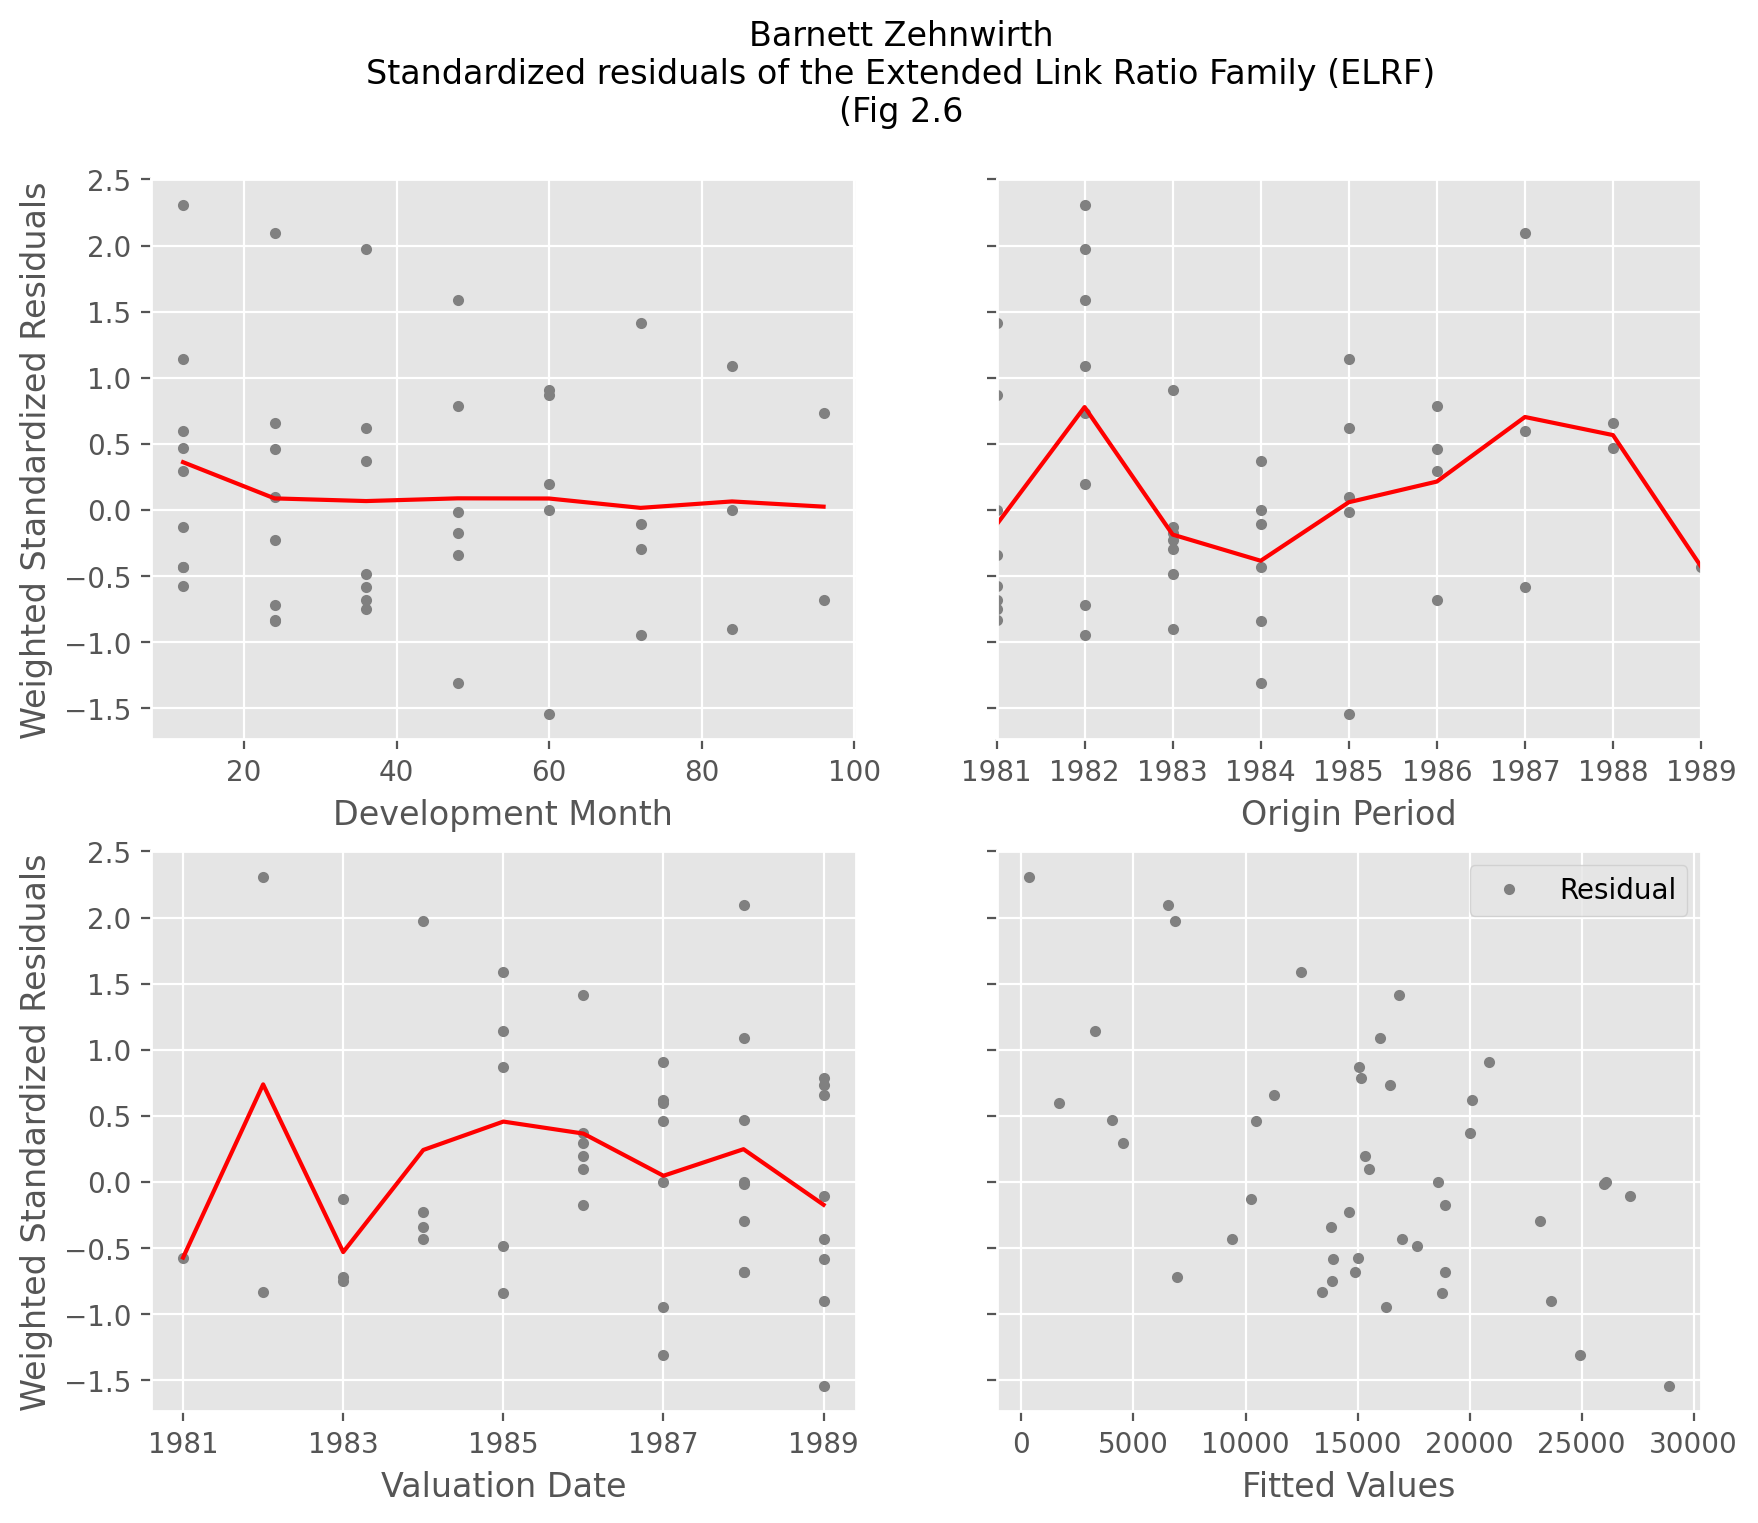

In [16]:
fig, ((ax00, ax01), (ax10, ax11)) = plt.subplots(ncols=2, nrows=2, figsize=(10,8))

# ax00
model.std_residuals_.T.plot(
    style='.', color='gray', legend=False, grid=True, ax=ax00,
    xlabel='Development Month', ylabel='Weighted Standardized Residuals',
)
model.std_residuals_.mean('origin').T.plot(
    style='r-', legend=False, ax=ax00,
)

# ax01
model.std_residuals_.plot(
    style='.', color='gray', legend=False, ax= ax01,
    xlabel='Origin Period',
)
model.std_residuals_.mean('development').plot(
    style='r-', legend=False, ax=ax01
)

# ax10
model.std_residuals_.dev_to_val().T.plot(
    style='.', color='gray', legend=False, grid=True, ax=ax10,
    xlabel='Valuation Date', ylabel='Weighted Standardized Residuals',
)
model.std_residuals_.dev_to_val().mean('origin').T.plot(
    style='r-', legend=False, ax=ax10,
)

# ax11
pd.concat([
    (raa[raa.valuation <raa.valuation_date] * model.ldf_.values).unstack().rename('Fitted Values'),
    model.std_residuals_.unstack().rename('Residual')
], axis=1).dropna().plot(
    style='.', color='gray', x='Fitted Values', y='Residual', ax = ax11, sharey= True
)



fig.suptitle('Barnett Zehnwirth\nStandardized residuals of the Extended Link Ratio Family (ELRF)\n(Fig 2.6')

In [17]:
raa

,12,24,36,48,60,72,84,96,108,120
1981,"5,012","8,269","10,907","11,805","13,539","16,181","18,009","18,608","18,662","18,834"
1982,106,"4,285","5,396","10,666","13,782","15,599","15,496","16,169","16,704",
1983,"3,410","8,992","13,873","16,141","18,735","22,214","22,863","23,466",,
1984,"5,655","11,555","15,766","21,266","23,425","26,083","27,067",,,
1985,"1,092","9,565","15,836","22,169","25,955","26,180",,,,
1986,"1,513","6,445","11,702","12,935","15,852",,,,,
1987,557,"4,020","10,946","12,314",,,,,,
1988,"1,351","6,947","13,112",,,,,,,
1989,"3,133","5,395",,,,,,,,
1990,"2,063",,,,,,,,,


In [18]:
raa[raa.valuation< raa.valuation_date] #omit the last column

,12,24,36,48,60,72,84,96,108
1981,"5,012","8,269","10,907","11,805","13,539","16,181","18,009","18,608","18,662"
1982,106,"4,285","5,396","10,666","13,782","15,599","15,496","16,169",
1983,"3,410","8,992","13,873","16,141","18,735","22,214","22,863",,
1984,"5,655","11,555","15,766","21,266","23,425","26,083",,,
1985,"1,092","9,565","15,836","22,169","25,955",,,,
1986,"1,513","6,445","11,702","12,935",,,,,
1987,557,"4,020","10,946",,,,,,
1988,"1,351","6,947",,,,,,,
1989,"3,133",,,,,,,,


In [19]:
model.ldf_.values

array([[[[2.99935865, 1.62352275, 1.27088812, 1.17167463, 1.11338489,
          1.04193464, 1.03326355, 1.01693648, 1.00921659]]]])

In [20]:
raa[raa.valuation<raa.valuation_date] * model.ldf_.values

,12,24,36,48,60,72,84,96,108
1981,"15,033","13,425","13,862","13,832","15,074","16,860","18,608","18,923","18,834"
1982,318,"6,957","6,858","12,497","15,345","16,253","16,011","16,443",
1983,"10,228","14,599","17,631","18,912","20,859","23,146","23,624",,
1984,"16,961","18,760","20,037","24,917","26,081","27,177",,,
1985,"3,275","15,529","20,126","25,975","28,898",,,,
1986,"4,538","10,464","14,872","15,156",,,,,
1987,"1,671","6,527","13,911",,,,,,
1988,"4,052","11,279",,,,,,,
1989,"9,397",,,,,,,,


In [21]:
fitted = (raa[raa.valuation<raa.valuation_date] * model.ldf_.values).unstack().rename('Fitted Values')
fitted

12   1981-01-01    15032.785560
     1982-01-01      317.932017
     1983-01-01    10227.813001
     1984-01-01    16961.373173
     1985-01-01     3275.299647
                       ...     
108  1985-01-01             NaN
     1986-01-01             NaN
     1987-01-01             NaN
     1988-01-01             NaN
     1989-01-01             NaN
Name: Fitted Values, Length: 81, dtype: float64

In [22]:
residuals = model.std_residuals_.unstack().rename('Residual')
residuals

12   1981-01-01   -0.572151
     1982-01-01    2.307508
     1983-01-01   -0.126737
     1984-01-01   -0.430543
     1985-01-01    1.139843
                     ...   
108  1985-01-01         NaN
     1986-01-01         NaN
     1987-01-01         NaN
     1988-01-01         NaN
     1989-01-01         NaN
Name: Residual, Length: 81, dtype: float64

<Axes: xlabel='Fitted Values'>

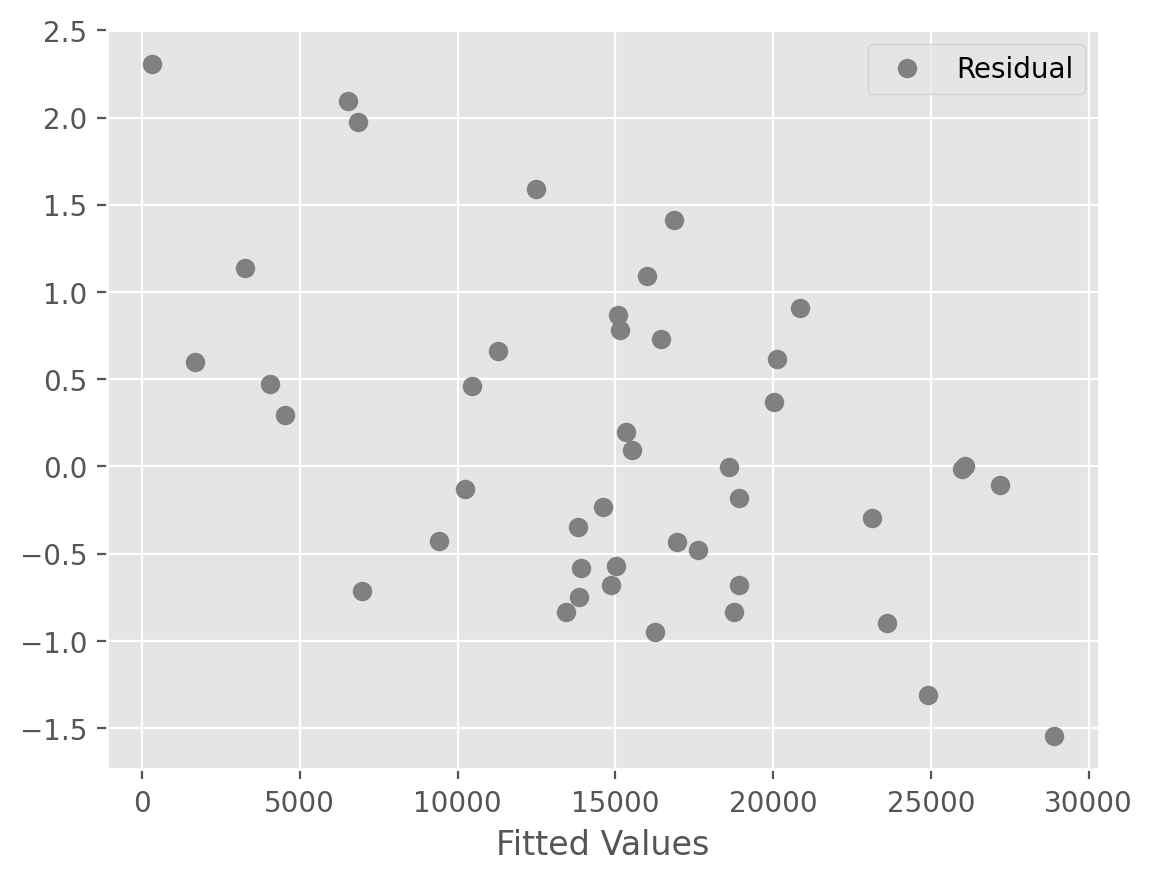

In [23]:
pd.concat([fitted, residuals], axis=1).dropna().plot(style='o', color='gray', x="Fitted Values", y="Residual")

In [24]:
model.std_residuals_.shape

(1, 1, 9, 9)

In [25]:
model.std_residuals_.iloc[...,:-1].mean('origin')

,12,24,36,48,60,72,84,96
1981,0.3612,0.0872,0.0671,0.0876,0.0864,0.0156,0.0643,0.0248


### Transformation

In [26]:
triangle = cl.load_sample('raa')
triangle

,12,24,36,48,60,72,84,96,108,120
1981,"5,012","8,269","10,907","11,805","13,539","16,181","18,009","18,608","18,662","18,834"
1982,106,"4,285","5,396","10,666","13,782","15,599","15,496","16,169","16,704",
1983,"3,410","8,992","13,873","16,141","18,735","22,214","22,863","23,466",,
1984,"5,655","11,555","15,766","21,266","23,425","26,083","27,067",,,
1985,"1,092","9,565","15,836","22,169","25,955","26,180",,,,
1986,"1,513","6,445","11,702","12,935","15,852",,,,,
1987,557,"4,020","10,946","12,314",,,,,,
1988,"1,351","6,947","13,112",,,,,,,
1989,"3,133","5,395",,,,,,,,
1990,"2,063",,,,,,,,,


- (1982,12) value is too low

In [27]:
dev = cl.Development(drop=('1982',12), drop_valuation='1988')
transformed_triangle = dev.fit_transform(triangle)
transformed_triangle.link_ratio.heatmap()

,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108,108-120
1981,1.6498,1.3190,1.0823,1.1469,1.1951,1.1130,1.0333,,1.0092
1982,,1.2593,1.9766,1.2921,1.1318,0.9934,,1.0331,
1983,2.6370,1.5428,1.1635,1.1607,1.1857,,1.0264,,
1984,2.0433,1.3644,1.3489,1.1015,,1.0377,,,
1985,8.7592,1.6556,1.3999,,1.0087,,,,
1986,4.2597,1.8157,,1.2255,,,,,
1987,7.2172,,1.1250,,,,,,
1988,,1.8874,,,,,,,
1989,1.7220,,,,,,,,


In [28]:
clrd = cl.load_sample('clrd')
clrd

,Triangle Summary
Valuation:,1997-12
Grain:,OYDY
Shape:,"(775, 6, 10, 10)"
Index:,"[GRNAME, LOB]"
Columns:,"[IncurLoss, CumPaidLoss, BulkLoss, EarnedPremDIR, EarnedPremCeded, EarnedPremNet]"


In [29]:
clrd['LOB'].unique()

array(['othliab', 'ppauto', 'comauto', 'wkcomp', 'prodliab', 'medmal'],
      dtype=object)

In [30]:
clrd = clrd[clrd['LOB'] == 'wkcomp']['CumPaidLoss']
clrd

,Triangle Summary
Valuation:,1997-12
Grain:,OYDY
Shape:,"(132, 1, 10, 10)"
Index:,"[GRNAME, LOB]"
Columns:,[CumPaidLoss]


In [31]:
clrd.sum()

,12,24,36,48,60,72,84,96,108,120
1988,"285,804","638,532","865,100","996,363","1,084,351","1,133,188","1,169,749","1,196,917","1,229,203","1,241,715"
1989,"307,720","684,140","916,996","1,065,674","1,154,072","1,210,479","1,249,886","1,291,512","1,308,706",
1990,"320,124","757,479","1,017,144","1,169,014","1,258,975","1,315,368","1,368,374","1,394,675",,
1991,"347,417","793,749","1,053,414","1,209,556","1,307,164","1,381,645","1,414,747",,,
1992,"342,982","781,402","1,014,982","1,172,915","1,281,864","1,328,801",,,,
1993,"342,385","743,433","959,147","1,113,314","1,187,581",,,,,
1994,"351,060","750,392","993,751","1,114,842",,,,,,
1995,"343,841","768,575","962,081",,,,,,,
1996,"381,484","736,040",,,,,,,,
1997,"340,132",,,,,,,,,


In [32]:
dev = cl.Development().fit(clrd.sum())
dev.transform(clrd)

,Triangle Summary
Valuation:,1997-12
Grain:,OYDY
Shape:,"(132, 1, 10, 10)"
Index:,"[GRNAME, LOB]"
Columns:,[CumPaidLoss]


### Groupby

Pick volume-weighted development patterns for each line-of-business and subsequently apply them to each company within the line of business.

In [34]:
clrd = cl.load_sample('clrd')['CumPaidLoss']
clrd = cl.Development(groupby="LOB").fit_transform(clrd)

clrd.shape, clrd.ldf_.shape

((775, 1, 10, 10), (6, 1, 1, 9))

Have original grain in the clrd triangle, but we have six sets of development patterns, one for each LOB.

- `DevelopmentConstant`: Industry LDFs hard-coded
- `IncrementalAdditive`: Exposure-adjusted development (Pure Premium being developed instead of the actual loss)

In [39]:
tri = cl.load_sample('ia_sample')
ia = cl.IncrementalAdditive().fit(
    X=tri['loss'],
    sample_weight=tri['exposure'].latest_diagonal
)

ia.incremental_.round(0)

,12,24,36,48,60,72
2000,"1,001.00",854.00,568.00,565.00,347.00,148.00
2001,"1,113.00",990.00,671.00,648.00,422.00,164.00
2002,"1,265.00","1,168.00",800.00,744.00,482.00,195.00
2003,"1,490.00","1,383.00","1,007.00",849.00,543.00,220.00
2004,"1,725.00","1,536.00","1,068.00",984.00,629.00,255.00
2005,"1,889.00","1,811.00","1,256.00","1,157.00",740.00,300.00


In [ ]:
tri = cl.load_sample('ia_sample')
print(tri.to_json())

{"metadata": "{\"is_val_tri\": false, \"is_cumulative\": true, \"is_pattern\": false, \"columns\": [\"loss\", \"exposure\"]}", "data": "{\"columns\":[\"Total\",\"origin\",\"valuation\",\"loss\",\"exposure\"],\"index\":[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],\"data\":[[\"Total\",946684800000000000,978307199999999999,1001.0,4025.0],[\"Total\",946684800000000000,1009843199999999999,854.0,0.0],[\"Total\",946684800000000000,1041379199999999999,568.0,0.0],[\"Total\",946684800000000000,1072915199999999999,565.0,0.0],[\"Total\",946684800000000000,1104537599999999999,347.0,0.0],[\"Total\",946684800000000000,1136073599999999999,148.0,0.0],[\"Total\",978307200000000000,1009843199999999999,1113.0,4456.0],[\"Total\",978307200000000000,1041379199999999999,990.0,0.0],[\"Total\",978307200000000000,1072915199999999999,671.0,0.0],[\"Total\",978307200000000000,1104537599999999999,648.0,0.0],[\"Total\",978307200000000000,1136073599999999999,422.0,0.0],[\"Total\",1009843200000000000,10413791

In [8]:
tri['loss'].to_clipboard()